# Keras Tuner | Hyperparameter Tuning

# Dependency Installation

In [4]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


# Import Libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [17]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras.optimizers import Adam, SGD, RMSprop, Adadelta, Nadam

from keras.losses import binary_crossentropy

from keras.activations import relu, leaky_relu, sigmoid, tanh, elu, selu, celu

# Load Dataset

In [7]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.corr()['Outcome']

,Outcome
Pregnancies,0.221898
Glucose,0.466581
BloodPressure,0.065068
SkinThickness,0.074752
Insulin,0.130548
BMI,0.292695
DiabetesPedigreeFunction,0.173844
Age,0.238356
Outcome,1.000000


# Train Test Split

In [12]:
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape, X_test.shape

((614, 8), (154, 8))

# Scale Data

In [16]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Default Model

In [22]:
X_train.shape[1]

8

In [26]:
model1 = Sequential()
model1.add(Input(shape=(X_train.shape[1],)))

model1.add(Dense(units=64, activation=celu))
model1.add(Dropout(0.5))
model1.add(Dense(units=32, activation=selu))
model1.add(Dropout(0.3))
model1.add(Dense(units=16, activation=elu))
model1.add(Dropout(0.2))
model1.add(Dense(units=8, activation=leaky_relu))
model1.add(Dropout(0.1))

model1.add(Dense(units=1, activation=sigmoid))

display(model1.summary())

model1.compile(optimizer=Adam(0.01), loss=binary_crossentropy, metrics=['accuracy'])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

None

In [27]:
history1 = model1.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

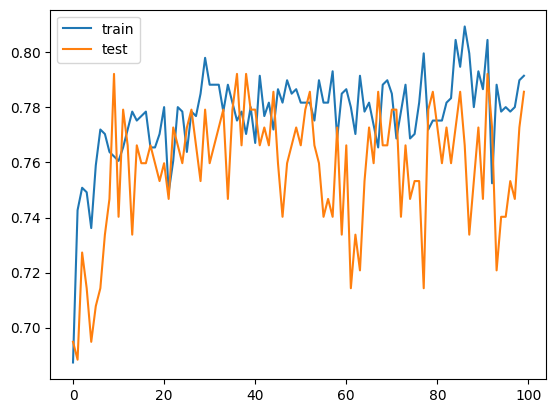

In [29]:
plt.plot(history1.history['accuracy'], label='train')
plt.plot(history1.history['val_accuracy'], label='test')
plt.legend()
plt.show()

In [33]:
history1.history['val_accuracy'][-1]

0.7857142686843872

# Keras Tuner - `Optimizer`

```python
def model_builder(hp):
  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=(28, 28)))

  # Tune the number of units in the first Dense layer
  # Choose an optimal value between 32-512
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
  model.add(keras.layers.Dense(units=hp_units, activation='relu'))
  model.add(keras.layers.Dense(10))

  # Tune the learning rate for the optimizer
  # Choose an optimal value from 0.01, 0.001, or 0.0001
  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

  model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])

  return model


tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5)
```

In [46]:
def model_build(hp):
    model2 = Sequential()

    # Input Layer
    model2.add(Input(shape=(X_train.shape[1],)))

    # Hidden Layers
    model2.add(Dense(64, activation="celu"))
    model2.add(Dropout(0.5))

    model2.add(Dense(32, activation="selu"))
    model2.add(Dropout(0.3))

    model2.add(Dense(16, activation="elu"))
    model2.add(Dropout(0.2))

    # Output Layer
    model2.add(Dense(1, activation="sigmoid"))

    # Learning rate hyperparameter
    learning_rate = hp.Float(
        "learning_rate",
        min_value=1e-4,
        max_value=1e-2,
        sampling="LOG",
        default=1e-3
    )

    # Optimizer choice hyperparameter (string)
    optim_name = hp.Choice(
        "optimizer",
        values=["adam", "sgd", "rmsprop", "adadelta", "nadam"]
    )

    # Create optimizer object dynamically
    optimizer_dict = {
        "adam": Adam(learning_rate),
        "sgd": SGD(learning_rate),
        "rmsprop": RMSprop(learning_rate),
        "adadelta": Adadelta(learning_rate),
        "nadam": Nadam(learning_rate),
    }
    optimizer = optimizer_dict[optim_name]

    model2.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model2

## Random Search

In [48]:
keras_tuner1 = kt.RandomSearch(
    model_build,
    objective = 'val_loss',
    max_trials = 5,
    directory = 'diabetes_tuning',
    project_name = 'diabetes_tuning1'
)

In [49]:
keras_tuner1.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Trial 5 Complete [00h 00m 13s]
val_loss: 0.5056175589561462

Best val_loss So Far: 0.4868607819080353
Total elapsed time: 00h 01m 14s


## Search Summary

In [50]:
keras_tuner1.results_summary()

Results summary
Results in diabetes_tuning/diabetes_tuning1
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 3 summary
Hyperparameters:
learning_rate: 0.0012630972366025235
optimizer: nadam
Score: 0.4868607819080353

Trial 4 summary
Hyperparameters:
learning_rate: 0.00015171749206187922
optimizer: rmsprop
Score: 0.5056175589561462

Trial 2 summary
Hyperparameters:
learning_rate: 0.00018344650778322566
optimizer: adam
Score: 0.506742000579834

Trial 0 summary
Hyperparameters:
learning_rate: 0.0018444947455105915
optimizer: adadelta
Score: 0.6557956337928772

Trial 1 summary
Hyperparameters:
learning_rate: 0.003263609494069065
optimizer: adadelta
Score: 0.7402207255363464


## Search Results

In [51]:
keras_tuner1.get_best_hyperparameters()[0].values

{'learning_rate': 0.0012630972366025235, 'optimizer': 'nadam'}

## Re-Train Model

In [53]:
model2 = keras_tuner1.get_best_models()[0]

In [54]:
history2 = model2.fit(
    X_train, y_train,
    epochs=300,
    initial_epoch=51,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
    )

## Accuracy Check

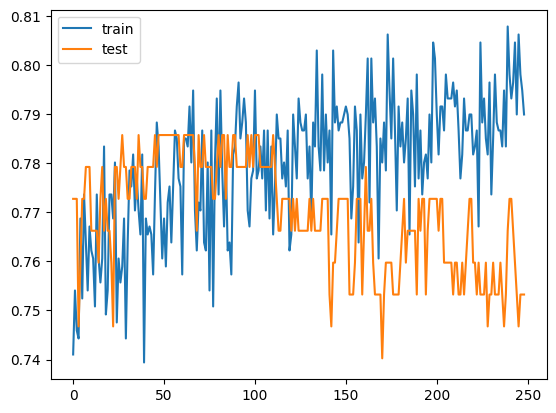

In [55]:
plt.plot(history2.history['accuracy'], label='train')
plt.plot(history2.history['val_accuracy'], label='test')
plt.legend()
plt.show()

In [56]:
history2.history['val_accuracy'][-1]

0.7532467246055603

# Node Per Layer - Keras_Tuner

In [63]:
def model_build(hp):
    model2 = Sequential()

    # Input Layer
    model2.add(Input(shape=(X_train.shape[1],)))

    # Hidden Layers
    units1 = hp.Choice('units1', values=[8, 16, 32, 64, 128, 256])
    dropout1 = hp.Float('dropout1', min_value=0.1, max_value=0.9, step=0.1)
    model2.add(Dense(units=units1, activation="celu"))
    model2.add(Dropout(dropout1))

    units2 = hp.Choice('units2', values=[8, 16, 32, 64, 128, 256])
    dropout2 = hp.Float('dropout2', min_value=0.1, max_value=0.9, step=0.1)
    model2.add(Dense(units=units2, activation="selu"))
    model2.add(Dropout(dropout2))

    units3 = hp.Choice('units3', values=[8, 16, 32, 64, 128, 256])
    dropout3 = hp.Float('dropout3', min_value=0.1, max_value=0.9, step=0.1)
    model2.add(Dense(units=units3, activation="elu"))
    model2.add(Dropout(dropout3))

    # Output Layer
    model2.add(Dense(1, activation="sigmoid"))

    model2.compile(
        optimizer=Nadam(learning_rate=0.00126309),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model2

## Random Search

In [64]:
tuner2 = kt.RandomSearch(
    model_build,
    objective = 'val_loss',
    max_trials = 5,
    directory = 'diabetes_tuning',
    project_name = 'diabetes_tuning2'
)

In [65]:
tuner2.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Trial 5 Complete [00h 00m 14s]
val_loss: 0.4993017017841339

Best val_loss So Far: 0.48898980021476746
Total elapsed time: 00h 02m 34s


## Search Summary

In [66]:
tuner2.results_summary()

Results summary
Results in diabetes_tuning/diabetes_tuning2
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 3 summary
Hyperparameters:
units1: 32
dropout1: 0.8
units2: 128
dropout2: 0.9
units3: 256
dropout3: 0.30000000000000004
Score: 0.48898980021476746

Trial 2 summary
Hyperparameters:
units1: 128
dropout1: 0.7000000000000001
units2: 256
dropout2: 0.5
units3: 256
dropout3: 0.30000000000000004
Score: 0.4920848608016968

Trial 4 summary
Hyperparameters:
units1: 16
dropout1: 0.4
units2: 128
dropout2: 0.30000000000000004
units3: 16
dropout3: 0.6
Score: 0.4993017017841339

Trial 1 summary
Hyperparameters:
units1: 16
dropout1: 0.4
units2: 64
dropout2: 0.6
units3: 8
dropout3: 0.30000000000000004
Score: 0.5096240043640137

Trial 0 summary
Hyperparameters:
units1: 16
dropout1: 0.9
units2: 16
dropout2: 0.8
units3: 64
dropout3: 0.2
Score: 0.5982592105865479


## Search Result

In [69]:
tuner2.get_best_hyperparameters()[0].values

{'units1': 32,
 'dropout1': 0.8,
 'units2': 128,
 'dropout2': 0.9,
 'units3': 256,
 'dropout3': 0.30000000000000004}

## Re-Train Model

In [72]:
model3 = tuner2.get_best_models()[0]
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,793 (147.63 KB)

 Trainable params: 37,793 (147.63 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
history3 = model3.fit(
    X_train, y_train,
    epochs=200,
    initial_epoch=51,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

## Accuracy Check

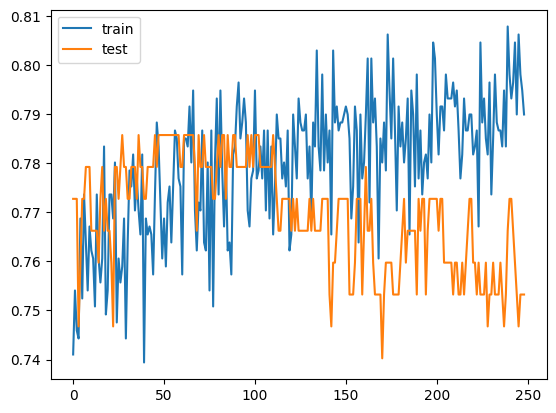

In [75]:
plt.plot(history2.history['accuracy'], label='train')
plt.plot(history2.history['val_accuracy'], label='test')
plt.legend()
plt.show()

In [76]:
history3.history['val_accuracy'][-1]

0.7337662577629089

# Layer Number - Keras_Tuner

In [97]:
def model_build(hp):
    modelx = Sequential()

    # Input Layer
    modelx.add(Input(shape=(X_train.shape[1],)))

    # Hidden Layers
    for i in range(hp.Int('num_layers', 2, 10)):
        activation = hp.Choice('activation_'+str(i), ['celu', 'selu', 'elu', 'relu', 'leaky_relu'])
        modelx.add(Dense(128, activation=activation))
        modelx.add(Dropout(0.7))

    # Output Layer
    modelx.add(Dense(1, activation="sigmoid"))

    modelx.compile(
        optimizer=Nadam(learning_rate=0.00126309),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return modelx

## Random Search

In [99]:
tuner3 = kt.RandomSearch(
    model_build,
    objective = 'val_loss',
    max_trials = 5,
    directory = 'diabetes_tuning',
    project_name = 'diabetes_tuning3xd'
)

In [100]:
tuner3.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Trial 5 Complete [00h 00m 24s]
val_loss: 0.6518157124519348

Best val_loss So Far: 0.5023190975189209
Total elapsed time: 00h 01m 40s


## Search Summary

In [101]:
tuner3.get_best_hyperparameters()[0].values

{'num_layers': 4,
 'activation_0': 'relu',
 'activation_1': 'leaky_relu',
 'activation_2': 'celu',
 'activation_3': 'leaky_relu',
 'activation_4': 'selu',
 'activation_5': 'elu',
 'activation_6': 'leaky_relu',
 'activation_7': 'celu',
 'activation_8': 'celu'}

In [102]:
tuner3.results_summary()

Results summary
Results in diabetes_tuning/diabetes_tuning3xd
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 3 summary
Hyperparameters:
num_layers: 4
activation_0: relu
activation_1: leaky_relu
activation_2: celu
activation_3: leaky_relu
activation_4: selu
activation_5: elu
activation_6: leaky_relu
activation_7: celu
activation_8: celu
Score: 0.5023190975189209

Trial 2 summary
Hyperparameters:
num_layers: 4
activation_0: elu
activation_1: celu
activation_2: elu
activation_3: selu
activation_4: elu
activation_5: relu
activation_6: selu
activation_7: leaky_relu
activation_8: elu
Score: 0.5116222500801086

Trial 0 summary
Hyperparameters:
num_layers: 7
activation_0: selu
activation_1: leaky_relu
activation_2: celu
activation_3: celu
activation_4: celu
activation_5: celu
activation_6: celu
Score: 0.6165092587471008

Trial 1 summary
Hyperparameters:
num_layers: 9
activation_0: celu
activation_1: leaky_relu
activation_2: leaky_relu
activation_3: celu
activation_4:

## Re-Train Model

In [103]:
model4 = tuner3.get_best_models()[0]
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,817 (198.50 KB)

 Trainable params: 50,817 (198.50 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
history4 = model4.fit(
    X_train, y_train,
    epochs=200,
    initial_epoch=51,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

## Accuracy Check

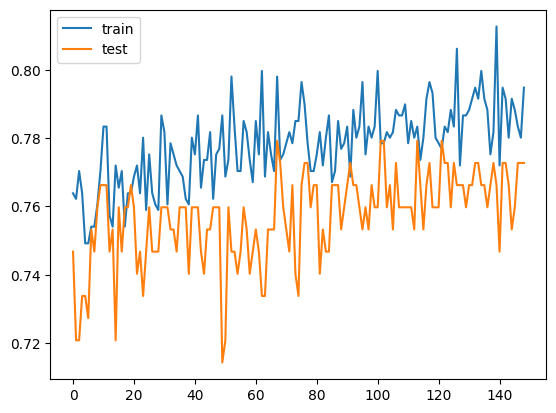

In [104]:
plt.plot(history4.history['accuracy'], label='train')
plt.plot(history4.history['val_accuracy'], label='test')
plt.legend()
plt.show()

In [105]:
history4.history['val_accuracy'][-1]

0.7727272510528564

 # Total Tunner

In [107]:
def model_build(hp):
    modelx = Sequential()

    # Input Layer
    modelx.add(Input(shape=(X_train.shape[1],)))

    # Hidden Layers
    for i in range(hp.Int('num_layers', 2, 10)):
        activation = hp.Choice('activation_'+str(i), ['celu', 'selu', 'elu', 'relu', 'leaky_relu'])
        unit = hp.Choice('units_'+str(i), [8, 16, 32, 64, 128, 256])
        dropout = hp.Float('dropout_'+str(i), min_value=0.1, max_value=0.9, step=0.1)

        modelx.add(Dense(units=unit, activation=activation))
        modelx.add(Dropout(dropout))

    # Output Layer
    modelx.add(Dense(1, activation="sigmoid"))

    optimizer = hp.Choice(
        "optimizer",
        values=["adam", "sgd", "rmsprop", "adadelta", "nadam"]
    )

    modelx.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return modelx


## Random Search

In [108]:
tuner4 = kt.RandomSearch(
    model_build,
    objective = 'val_loss',
    max_trials = 10,
    directory = 'diabetes_tuning',
    project_name = 'diabetes_tuning4'
)

In [109]:
tuner4.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Trial 10 Complete [00h 00m 14s]
val_loss: 0.5123233199119568

Best val_loss So Far: 0.48111972212791443
Total elapsed time: 00h 02m 47s


## Search Summary

In [110]:
tuner4.get_best_hyperparameters()[0].values

{'num_layers': 7,
 'activation_0': 'celu',
 'units_0': 256,
 'dropout_0': 0.30000000000000004,
 'activation_1': 'leaky_relu',
 'units_1': 256,
 'dropout_1': 0.7000000000000001,
 'optimizer': 'nadam',
 'activation_2': 'relu',
 'units_2': 256,
 'dropout_2': 0.1,
 'activation_3': 'relu',
 'units_3': 32,
 'dropout_3': 0.5,
 'activation_4': 'elu',
 'units_4': 32,
 'dropout_4': 0.6,
 'activation_5': 'elu',
 'units_5': 16,
 'dropout_5': 0.5,
 'activation_6': 'celu',
 'units_6': 64,
 'dropout_6': 0.6,
 'activation_7': 'selu',
 'units_7': 256,
 'dropout_7': 0.8,
 'activation_8': 'leaky_relu',
 'units_8': 8,
 'dropout_8': 0.6}

In [111]:
tuner4.results_summary()

Results summary
Results in diabetes_tuning/diabetes_tuning4
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 08 summary
Hyperparameters:
num_layers: 7
activation_0: celu
units_0: 256
dropout_0: 0.30000000000000004
activation_1: leaky_relu
units_1: 256
dropout_1: 0.7000000000000001
optimizer: nadam
activation_2: relu
units_2: 256
dropout_2: 0.1
activation_3: relu
units_3: 32
dropout_3: 0.5
activation_4: elu
units_4: 32
dropout_4: 0.6
activation_5: elu
units_5: 16
dropout_5: 0.5
activation_6: celu
units_6: 64
dropout_6: 0.6
activation_7: selu
units_7: 256
dropout_7: 0.8
activation_8: leaky_relu
units_8: 8
dropout_8: 0.6
Score: 0.48111972212791443

Trial 06 summary
Hyperparameters:
num_layers: 6
activation_0: selu
units_0: 32
dropout_0: 0.30000000000000004
activation_1: celu
units_1: 32
dropout_1: 0.4
optimizer: nadam
activation_2: relu
units_2: 128
dropout_2: 0.9
activation_3: selu
units_3: 32
dropout_3: 0.30000000000000004
activation_4: celu
units_4: 128
dropout

## Re-Train Model

In [114]:
model5 = tuner4.get_best_models()[0]
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,849 (565.82 KB)

 Trainable params: 144,849 (565.82 KB)

 Non-trainable params: 0 (0.00 B)

In [115]:
history5 = model5.fit(
    X_train, y_train,
    epochs=300,
    initial_epoch=51,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

## Accuracy Check

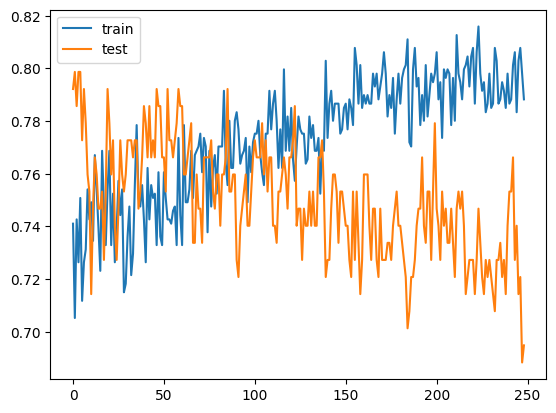

In [116]:
plt.plot(history5.history['accuracy'], label='train')
plt.plot(history5.history['val_accuracy'], label='test')
plt.legend()
plt.show()

In [117]:
history5.history['val_accuracy'][-1]

0.6948052048683167